## Imports et chargement des données

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.geometry import box

# Charger les données déjà préparées
edges = gpd.read_file("../data/processed/abidjan_roads.gpkg")
abidjan = gpd.read_file("../data/raw/gadm41_CIV_4.shp")
abidjan = abidjan[abidjan['NAME_1'] == 'Abidjan'].copy()

# Vérifier que les CRS sont identiques
print("CRS routes :", edges.crs)
print("CRS admin  :", abidjan.crs)
print(f"Nombre de segments routiers : {len(edges)}")

CRS routes : EPSG:4326
CRS admin  : EPSG:4326
Nombre de segments routiers : 145963


## Filtrer les routes principales

In [2]:
# Voir les types de routes disponibles
print(edges['highway'].value_counts())

highway
residential                                    128611
tertiary                                         8732
unclassified                                     4059
secondary                                        2663
primary                                           820
trunk                                             285
motorway_link                                     167
motorway                                          136
primary_link                                      127
trunk_link                                        113
secondary_link                                     91
tertiary_link                                      58
['residential', 'unclassified']                    34
living_street                                      22
['residential', 'tertiary']                        16
['unclassified', 'tertiary']                       10
['residential', 'living_street']                    4
['unclassified', 'primary_link']                    3
busway              

## Filtrer les routes à fort trafic

In [3]:
# Routes susceptibles d'être embouteillées
types_importants = [
    'motorway', 'motorway_link',
    'trunk', 'trunk_link', 
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary'
]

# Filtrer
routes_principales = edges[edges['highway'].isin(types_importants)].copy()

print(f"Routes principales : {len(routes_principales)} segments")
print(f"Soit {len(routes_principales)/len(edges)*100:.1f}% du réseau total")

# Recadrer sur Abidjan uniquement
routes_abidjan = gpd.clip(routes_principales, abidjan.union_all())
print(f"Routes dans Abidjan : {len(routes_abidjan)} segments")

Routes principales : 13134 segments
Soit 9.0% du réseau total
Routes dans Abidjan : 13126 segments


## Carte des routes par type

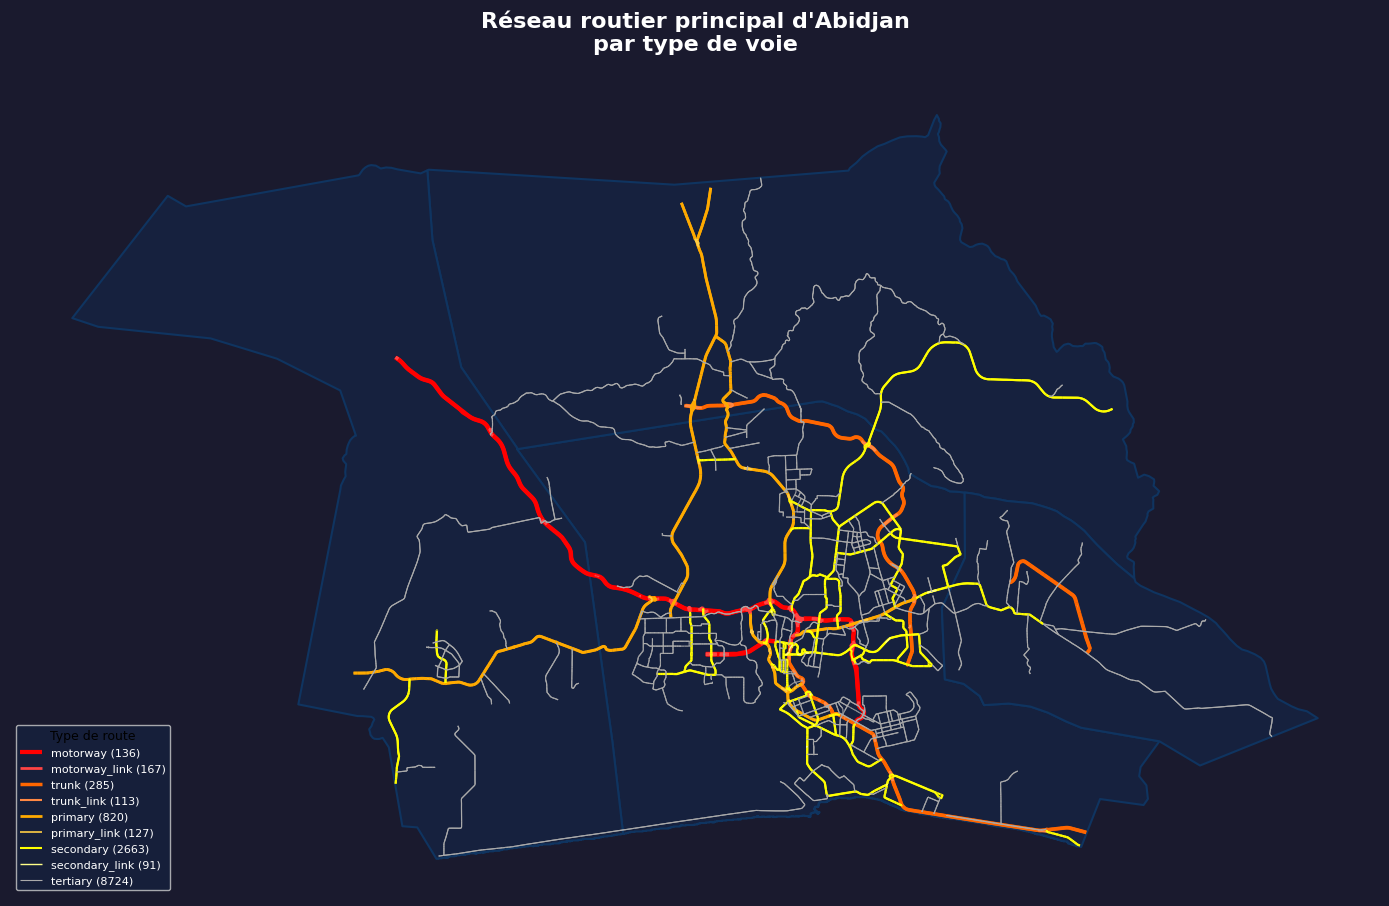

Carte sauvegardée !


In [5]:
# Couleurs par type de route
couleurs = {
    'motorway': '#FF0000',
    'motorway_link': '#FF4444',
    'trunk': '#FF6600',
    'trunk_link': '#FF8844',
    'primary': '#FFAA00',
    'primary_link': '#FFCC44',
    'secondary': '#FFFF00',
    'secondary_link': '#FFFF88',
    'tertiary': '#AAAAAA'
}

epaisseurs = {
    'motorway': 3.0,
    'motorway_link': 2.0,
    'trunk': 2.5,
    'trunk_link': 1.5,
    'primary': 2.0,
    'primary_link': 1.2,
    'secondary': 1.5,
    'secondary_link': 1.0,
    'tertiary': 0.8
}

fig, ax = plt.subplots(figsize=(14, 12), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Fond : communes d'Abidjan
abidjan.plot(ax=ax, color='#16213e', edgecolor='#0f3460', linewidth=1.5)

# Tracer chaque type de route
for highway_type, color in couleurs.items():
    subset = routes_abidjan[routes_abidjan['highway'] == highway_type]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, 
                   linewidth=epaisseurs[highway_type],
                   label=f"{highway_type} ({len(subset)})")

# Légende
ax.legend(loc='lower left', fontsize=8, 
          facecolor='#16213e', labelcolor='white',
          title='Type de route', title_fontsize=9)

plt.title("Réseau routier principal d'Abidjan\npar type de voie", 
          fontsize=16, color='white', fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

import os
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/routes_principales_abidjan.png", 
            dpi=150, bbox_inches="tight", facecolor='#1a1a2e')
plt.show()
print("Carte sauvegardée !")

## Densité routière par commune
# C'est ici que la géomatique + data science se combinent vraiment

In [6]:
# Reprojeter en métrique pour calculer les distances (UTM zone 30N)
routes_m = routes_abidjan.to_crs(epsg=32630)
abidjan_m = abidjan.to_crs(epsg=32630)

# Calculer la longueur totale des routes par commune
resultats = []

for idx, commune in abidjan_m.iterrows():
    # Découper les routes dans cette commune
    routes_commune = gpd.clip(routes_m, commune.geometry)
    
    # Longueur totale en km
    longueur_km = routes_commune.geometry.length.sum() / 1000
    
    # Superficie en km²
    superficie_km2 = commune.geometry.area / 1_000_000
    
    # Densité routière (km de route / km²)
    densite = longueur_km / superficie_km2 if superficie_km2 > 0 else 0
    
    resultats.append({
        'commune': commune['NAME_4'],
        'longueur_km': round(longueur_km, 2),
        'superficie_km2': round(superficie_km2, 2),
        'densite_routiere': round(densite, 3)
    })

df_densite = pd.DataFrame(resultats)
print(df_densite.sort_values('densite_routiere', ascending=False))

         commune  longueur_km  superficie_km2  densite_routiere
0  Abidjan-Ville      1234.02          622.32             1.983
2    Bingerville       152.77          207.14             0.738
1         Anyama       286.13          647.41             0.442
3         Songon       243.38          629.67             0.387


## Carte choroplèthe de la densité routière

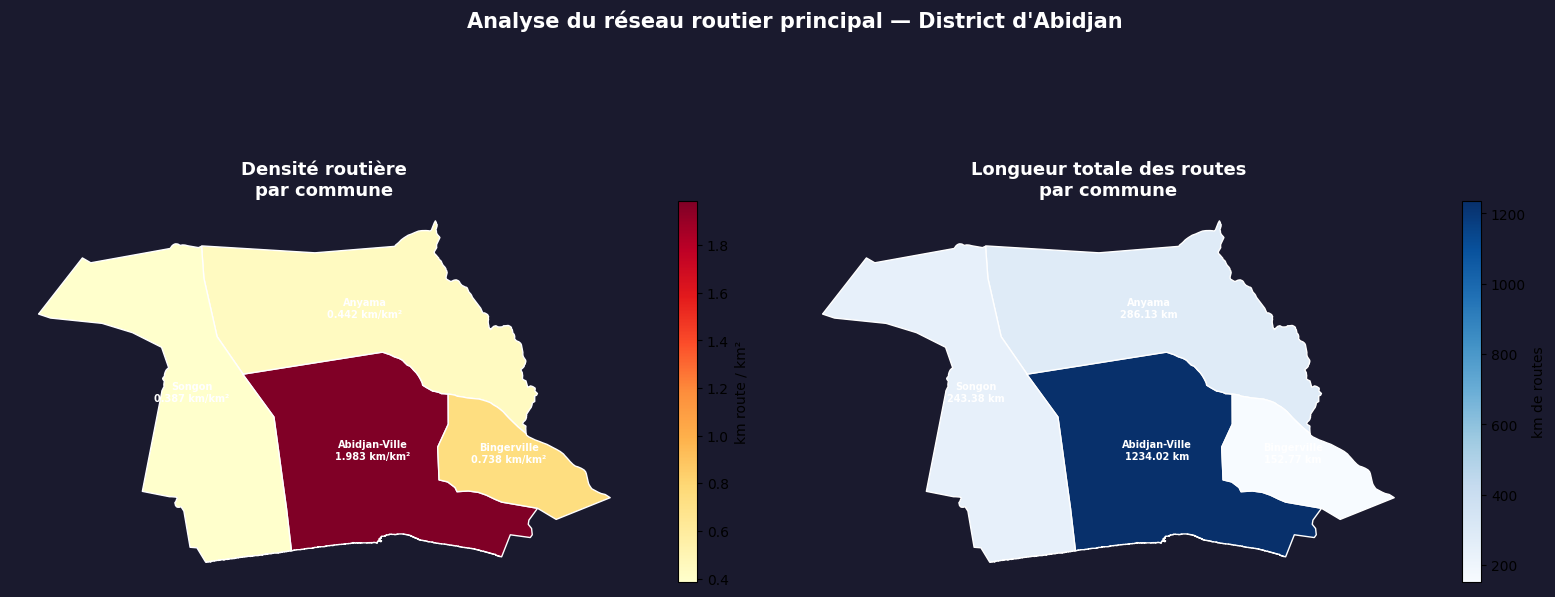

Carte choroplèthe sauvegardée !


In [7]:
# Fusionner les résultats avec la géométrie
abidjan_densite = abidjan.merge(df_densite, left_on='NAME_4', right_on='commune')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1a1a2e')

# --- Carte 1 : Densité routière ---
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
abidjan_densite.plot(ax=ax1,
                     column='densite_routiere',
                     cmap='YlOrRd',
                     edgecolor='white',
                     linewidth=1,
                     legend=True,
                     legend_kwds={'label': 'km route / km²', 'shrink': 0.6})

for idx, row in abidjan_densite.iterrows():
    ax1.annotate(f"{row['NAME_4']}\n{row['densite_routiere']} km/km²",
                xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                fontsize=7, ha='center', color='white', fontweight='bold')

ax1.set_title("Densité routière\npar commune", color='white', fontsize=13, fontweight='bold')
ax1.axis('off')

# --- Carte 2 : Longueur totale ---
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
abidjan_densite.plot(ax=ax2,
                     column='longueur_km',
                     cmap='Blues',
                     edgecolor='white',
                     linewidth=1,
                     legend=True,
                     legend_kwds={'label': 'km de routes', 'shrink': 0.6})

for idx, row in abidjan_densite.iterrows():
    ax2.annotate(f"{row['NAME_4']}\n{row['longueur_km']} km",
                xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                fontsize=7, ha='center', color='white', fontweight='bold')

ax2.set_title("Longueur totale des routes\npar commune", color='white', fontsize=13, fontweight='bold')
ax2.axis('off')

plt.suptitle("Analyse du réseau routier principal — District d'Abidjan",
             color='white', fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("../outputs/densite_routiere_abidjan.png", dpi=150,
            bbox_inches="tight", facecolor='#1a1a2e')
plt.show()
print("Carte choroplèthe sauvegardée !")

## Exporter les routes en GeoJSON

In [8]:
import json

# Reprojeter en WGS84 pour Leaflet
routes_export = routes_abidjan.to_crs(epsg=4326)

# Garder uniquement les colonnes utiles
routes_export = routes_export[['highway', 'name', 'length', 'geometry']].copy()

# Nettoyer les valeurs manquantes
routes_export['name'] = routes_export['name'].fillna('Route sans nom')
routes_export['length'] = routes_export['length'].round(1)

# Sauvegarder en GeoJSON
routes_export.to_file("../Data/Processed/routes_abidjan.geojson", driver="GeoJSON")

# Sauvegarder aussi les communes
abidjan_export = abidjan.to_crs(epsg=4326)
abidjan_export[['NAME_4', 'geometry']].to_file("../Data/Processed/communes_abidjan.geojson", driver="GeoJSON")

print("GeoJSON exportés !")
print(f"Taille routes : {len(routes_export)} segments")

GeoJSON exportés !
Taille routes : 13126 segments


## Intégrer les GeoJSON directement dans le HTML

In [10]:
import json

# Lire les GeoJSON
with open("../Data/Processed/routes_abidjan.geojson", "r", encoding="utf-8") as f:
    routes_json = json.load(f)

with open("../Data/Processed/communes_abidjan.geojson", "r", encoding="utf-8") as f:
    communes_json = json.load(f)

# Lire le HTML
with open("../outputs/carte_trafic_abidjan.html", "r", encoding="utf-8") as f:
    html = f.read()

# Injecter les données directement dans le HTML
injection = f"""<script>
const ROUTES_DATA = {json.dumps(routes_json)};
const COMMUNES_DATA = {json.dumps(communes_json)};
</script>"""

html = html.replace("</head>", injection + "\n</head>")

# Remplacer les fetch() par les données inline
html = html.replace(
    "fetch('../Data/Processed/communes_abidjan.geojson')\n  .then(r => r.json())",
    "Promise.resolve(COMMUNES_DATA)"
)
html = html.replace(
    "fetch('../Data/Processed/routes_abidjan.geojson')\n  .then(r => r.json())",
    "Promise.resolve(ROUTES_DATA)"
)

# Sauvegarder
with open("../outputs/carte_trafic_abidjan.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Données intégrées dans le HTML !")
print(f"Taille du fichier : {len(html) / 1024 / 1024:.1f} MB")

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/carte_trafic_abidjan.html'